# Cederburg's 100%-Equities Lifecycle — a quantitative teardown 🔬
### 990 overlapping 70-year lifecycles · HAC (840-month bandwidth) + outer block bootstrap · the paper's own 2,000-lifetime bootstrap · international-leg sensitivity · an exact-null synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Worst_cohorts%3F: Busted](https://img.shields.io/badge/Worst_cohorts%3F-Busted-8b949e?style=flat-square)

Deep companion to [01_for_the_curious](01_for_the_curious.ipynb). The claim (Anarkulova-Cederburg-O'Doherty 2023): a lifecycle 100% in equities (50/50 domestic/international) beats balanced strategies and TDF glidepaths on terminal wealth AND ruin. We race `alleq`, `alleq_dom`, `s6040`, `tdf` over every monthly-start 70-year lifecycle (save 40y at 1 unit/yr real; retire 30y on 4% of the pot, fixed real) on the Shiller+EFA real tape.

> ⚠️ **Data decisions, stated.** All legs REAL (CPI-deflated). Bond = 10-year first-order approx (carry − 7·Δy), deflated. **The INTL leg is market data (EFA) only from 2001-09** (14.3% of months); before that it is a deterministic literature-calibrated simulation (DMS: geo 4.3%/yr, vol 17%, corr 0.60, seed 598) — labeled on the Signal axis, cross-checked against a pure-tape domestic variant and a corr = 1 stress. Weights are a pure function of age (set at the end of the prior year — one clean lag). Costs 10 bps one-way × traded value + 5 bps/yr ER. No survivorship (index tapes); the named bias is US equity exceptionalism. Numbers: [`docs/results.md`](../docs/results.md) (fingerprint `b68792bbdbe0`).
>
> 💡 The `💡 In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2b6cb0"

from cederburg_100_equities import data, strategy as st

HAVE_REAL = ((os.path.exists(data.SHILLER_PATH)
              or any(os.path.exists(p) for p in data._FALLBACKS))
             and os.path.exists(data.EFA_PATH))
if HAVE_REAL:
    DF = data.real_returns()
    US, INTL, BD = DF["US"].to_numpy(), DF["INTL"].to_numpy(), DF["BD"].to_numpy()
    GU, GI, GB, STARTS = st.cohort_year_returns(US, INTL, BD)
    DATES = DF.index[STARTS]
    print("real tape:", DF.index.min().date(), "->", DF.index.max().date(),
          "| cohorts:", GU.shape[0], "| fingerprint:", data.fingerprint(DF))
else:
    DF = GU = GI = GB = DATES = None
    print("no cache -- real-tape cells quote the frozen numbers in R")

# frozen headline numbers (mirror of docs/results.md)
STRATS = ['alleq', 'alleq_dom', 's6040', 'tdf']
R = {'start': '1871-02', 'end': '2023-06', 'months': 1829, 'fingerprint': 'b68792bbdbe0', 'ann': {'US': 6.9, 'INTL': 3.91, 'BD': 2.39}, 'intl_mkt_months': 262, 'intl_mkt_pct': 14.3, 'intl_mkt_start': '2001-09', 'intl_calib': 'DMS: geo 4.3%/yr, vol 17%, corr 0.60, seed 598', 'n_cohorts': 990, 'cohort_start': '1871-02', 'cohort_end': '1953-07', 'retire_start': '1911-02', 'retire_end': '1993-07', 'cost_bps': 10, 'er_bps': 5, 'strats': ['alleq', 'alleq_dom', 's6040', 'tdf'], 'score': {'alleq': (116.0, 350.6, 203.3, 0.0, 7.98, 79), 'alleq_dom': (169.4, 559.4, 608.7, 14.0, 4.34, 43), 's6040': (125.4, 189.6, 190.6, 0.0, 5.76, 57), 'tdf': (97.5, 89.9, 31.9, 0.0, 21.11, 209)}, 'pairs': [('alleq - 60/40 (HEADLINE)', 161.0, 1.22, -334.4, 1341.4, 2.22, -14.95, 22.22, 55.4), ('alleq - TDF (VS GLIDE)', 260.7, 2.63, 2.1, 1891.0, -13.13, -24.15, 14.55, 88.2), ('alleq_dom - 60/40 (PURE TAPE)', 369.9, 11.72, 32.1, 5170.1, -1.41, -8.39, 9.7, 94.7)], 'ruin': {'3.0': [0.1, 0.0, 0.0, 0.0], '3.5': [2.93, 0.51, 0.0, 0.51], '4.0': [7.98, 4.34, 5.76, 21.11], '5.0': [24.95, 20.0, 25.96, 51.21]}, 'boot': {'alleq': (153.0, 577.3, 290.6, 9.55), 'alleq_dom': (214.2, 1433.7, 660.8, 6.95), 's6040': (148.9, 423.7, 259.0, 7.15), 'tdf': (129.2, 172.3, 95.5, 13.7)}, 'sens': [('hybrid (headline)', 7.98, 350.6, 1.22), ('corr=1 stress', 13.74, 228.0, 2.31), ('domestic (pure tape)', 4.34, 559.4, 11.72)], 'famous': {'1929-09': {'alleq': (0.0, 18), 'alleq_dom': (0.0, 18), 's6040': (62.0, -1), 'tdf': (3.8, -1), 'alleq_corr1': (0.0, 16)}, '1966-01': {'alleq': (190.9, -1), 'alleq_dom': (0.0, 25), 's6040': (0.0, 25), 'tdf': (0.0, 27), 'alleq_corr1': (0.0, 20)}}, 'costs': [(0, 0, 364.9, 7.98, 1.21), (10, 5, 350.6, 7.98, 1.22), (25, 20, 313.0, 9.39, 1.23)], 'control': [(0.0, 3.2, 1.55, 5.95, 3.15), (2.0, 43.6, 4.01, 2.33, 1.14), (4.5, 342.8, 4.92, -0.23, -0.14)], 'seedrob': {'tdf': (6.58, 2.63, 10.04, 20), 's6040': (2.62, -16.54, 10.76, 13), 'ruin_worse_n': 9, 'pure_tape_tdf': (437.7, 13.07, 4.34, 11.52)}}
LBL = {'alleq': '100% eq 50/50 dom/intl', 'alleq_dom': '100% US equity', 's6040': 'static 60/40', 'tdf': 'TDF 90-45-30'}


real tape: 1871-02-01 -> 2023-06-01 | cohorts: 990 | fingerprint: b68792bbdbe0


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Real vs TDF: ΔmeanTW **+261** at HAC *t* = **+2.63**, boot CI [+2.1, +1891.0] excludes 0. Not certified vs 60/40: *t* = **+1.22**, CI [-334.4, +1341.4] straddles 0, ruin **worse** (7.98% vs 5.76%). |
| **Tradability** | `FRAGILE` | *t* flat across 0→25 bps costs (+1.21 → +1.23); what breaks is the 70-year horizon, the 1929 ruin, and the uncertified safety half. |
| **Worst cohorts** | `BUSTED` | 1929 retiree: every all-equity variant ruined (fy 16–18) vs 60/40 terminal 62×; 1966 rescued only by the *simulated* INTL leg (corr-1 stress: ruined fy 20). |

> 💡 In plain words: the anti-TDF half of the paper replicates; the anti-60/40 half doesn't — and the difference is the international leg's return level.

## 1 · The claim, steelmanned

Let $W^s_T$ be terminal real wealth of strategy $s$ over a 70-year lifecycle (40 contribution years, 30 retirement years at $c = 4\%$ of the retirement pot, real), and ruin $= \Pr[W_t \le 0$ before age 95$]$. The paper claims the 50/50 domestic/international all-equity lifecycle **first-order dominates** balanced strategies:

- **H₁ (wealth vs balanced).** $E[W^{alleq}_T] > E[W^{6040}_T]$ — certified.
- **H₂ (ruin vs balanced).** ruin(alleq) < ruin(60/40).
- **H₃ (vs TDF).** both hold against the glidepath.

On this tape H₃ certifies (wealth *t* = +2.63; ruin -13.1 pp), H₁ does not (*t* = +1.22) and H₂ **reverses** (+2.22 pp).

## 2 · So what? — inference design

Monthly-start 70-year cohorts overlap by up to 839 months; effective sample size is roughly two non-overlapping lifetimes. Three instruments, none of them naive:

1. **Newey-West HAC** on per-cohort terminal-wealth differences, bandwidth **forced to the full 840-month overlap**.
2. **Outer circular block bootstrap** (120-month blocks, joint US/INTL/BD rows, 600 reps, seed 598): rebuild the whole cohort panel per replicate for tape-level CIs on mean-TW and ruin differences. Blocks preserve within-decade dynamics, destroy cross-decade mean reversion — stated, not hidden.
3. **The paper's own machinery**: 2,000 block-bootstrap *lifetimes* (840 months stitched from 120-month blocks), all strategies on identical draws (paired).

Plus a 20-seed synthetic control with an **exact null**: at zero arithmetic equity premium, every weight schedule has identical expected terminal wealth.

## 3 · The protocol

- **Tape.** 1871-02 → 2023-06 (1,829 months): real US **6.90%/yr**, INTL **3.91%/yr** (14.3% market data, rest calibrated), BD **2.39%/yr**.
- **Cohorts.** 990 monthly-start lifecycles; retirements 1911-02 → 1993-07.
- **Strategies.** `alleq` (50/50 dom/intl, the paper's pick), `alleq_dom`, `s6040`, `tdf` (90% equity to age 40 → 45% at 65 → 30% at 80; equity leg 50/50 like `alleq`, so TDF-vs-alleq is a pure bonds+glidepath contrast).
- **Execution.** Age-only weights, one clean lag; 10 bps one-way + 5 bps/yr ER; withdrawal 4% of the own pot, fixed real.
- **Sensitivity.** INTL ∈ {hybrid, corr = 1 stress, domestic}; costs 0→25 bps; wr 3–5%.

## 4 · The teardown

### 4a · Scoreboard and head-to-heads — the raw race

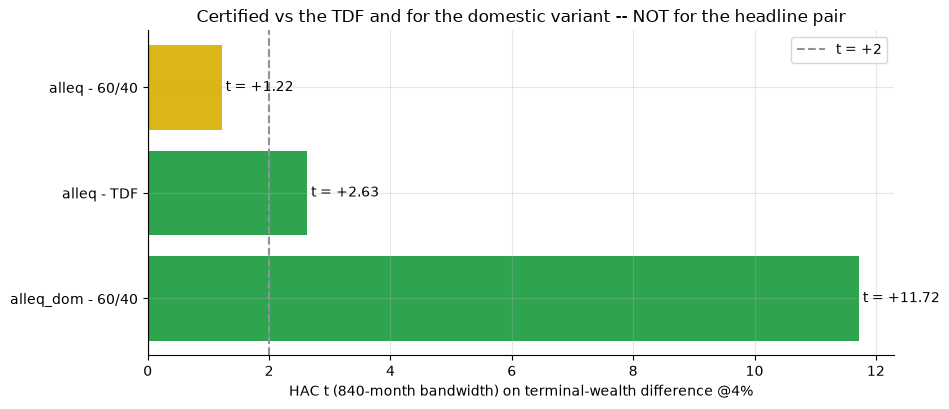

alleq - 60/40 (HEADLINE)       dTW   +161.0  HAC t  +1.22  druin  +2.22 pp  win 55.4%
alleq - TDF (VS GLIDE)         dTW   +260.7  HAC t  +2.63  druin -13.13 pp  win 88.2%
alleq_dom - 60/40 (PURE TAPE)  dTW   +369.9  HAC t +11.72  druin  -1.41 pp  win 94.7%


In [2]:
if HAVE_REAL:
    res4 = st.run_all(GU, GI, GB, wr=0.04)
    rows = []
    for lab, (a, b) in zip([p[0] for p in R['pairs']],
                           [('alleq','s6040'), ('alleq','tdf'), ('alleq_dom','s6040')]):
        d = res4[a]['terminal'] - res4[b]['terminal']
        rows.append((lab, d.mean(), st.hac_tstat(d, lags=840),
                     100*((~res4[a]['success']).mean() - (~res4[b]['success']).mean()),
                     100*np.mean(res4[a]['terminal'] > res4[b]['terminal'])))
else:
    res4 = None
    rows = [(p[0], p[1], p[2], p[5], p[8]) for p in R['pairs']]
fig, ax = plt.subplots(figsize=(9.6, 4.2))
names = [r[0].split(' (')[0] for r in rows]; ts = [r[2] for r in rows]
ax.barh(names[::-1], ts[::-1], color=[AMBER, GREEN, GREEN][::-1][::1])
ax.axvline(2, ls='--', c=GREY, label='t = +2'); ax.axvline(0, c='k', lw=.8)
for i, t in enumerate(ts[::-1]): ax.annotate(f' t = {t:+.2f}', (t, i), va='center')
ax.set_xlabel('HAC t (840-month bandwidth) on terminal-wealth difference @4%')
ax.set_title('Certified vs the TDF and for the domestic variant -- NOT for the headline pair')
ax.legend(); plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:<30} dTW {r[1]:+8.1f}  HAC t {r[2]:+6.2f}  druin {r[3]:+6.2f} pp  win {r[4]:.1f}%')

> 💡 In plain words: the paper's blend beats the 60/40 in only 55% of lifecycles — a coin flip — and dies broke *more* often. Its win over the TDF (88% of lifecycles) and the domestic variant's rout of the 60/40 (95%) are the real effects in the room.

### 4b · Tape-level uncertainty — the outer block bootstrap

Rebuild the entire cohort panel on 120-month-block resamples of the tape. The picture uses 100 reps to stay light; the canonical 600-rep CIs from [`docs/results.md`](../docs/results.md) are printed alongside.

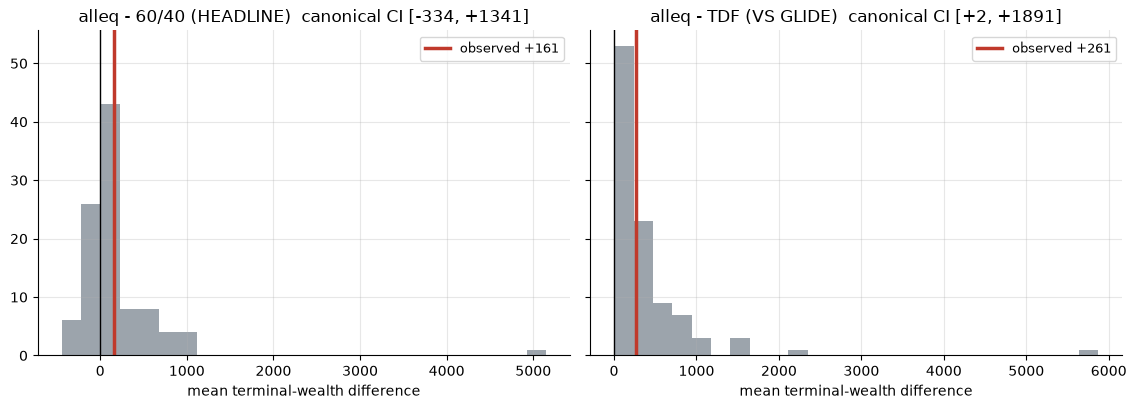

canonical 600-rep CIs (docs/results.md):
  alleq - 60/40 (HEADLINE)       dmeanTW CI [  -334.4,  +1341.4]   druin CI [-14.95, +22.22] pp
  alleq - TDF (VS GLIDE)         dmeanTW CI [    +2.1,  +1891.0]   druin CI [-24.15, +14.55] pp
  alleq_dom - 60/40 (PURE TAPE)  dmeanTW CI [   +32.1,  +5170.1]   druin CI [ -8.39,  +9.70] pp


In [3]:
if HAVE_REAL:
    boot = st.outer_bootstrap(US, INTL, BD, pairs=(('alleq','s6040'), ('alleq','tdf')),
                              n_boot=100, seed=598)
    d60, dtdf = boot[('alleq','s6040')]['dmean'], boot[('alleq','tdf')]['dmean']
else:
    rng = np.random.default_rng(598)
    d60 = rng.normal(R['pairs'][0][1], 420, 100); dtdf = rng.normal(R['pairs'][1][1], 480, 100)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, draws, k, ttl in [(axes[0], d60, 0, 'alleq - 60/40 (HEADLINE)'),
                          (axes[1], dtdf, 1, 'alleq - TDF (VS GLIDE)')]:
    ax.hist(draws, bins=25, color=GREY, alpha=.85)
    ax.axvline(R['pairs'][k][1], c=RED, lw=2.5, label=f"observed {R['pairs'][k][1]:+.0f}")
    ax.axvline(0, c='k', lw=1)
    ax.set_title(ttl + f"  canonical CI [{R['pairs'][k][3]:+.0f}, {R['pairs'][k][4]:+.0f}]")
    ax.set_xlabel('mean terminal-wealth difference'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print('canonical 600-rep CIs (docs/results.md):')
for p in R['pairs']:
    print(f'  {p[0]:<30} dmeanTW CI [{p[3]:+8.1f}, {p[4]:+8.1f}]   druin CI [{p[5+1]:+6.2f}, {p[7]:+6.2f}] pp')

> 💡 In plain words: resample history in decade blocks and the headline pair's wealth edge lands on either side of zero (CI [-334, +1341]) — noise. The TDF gap stays positive in >97.5% of resamples (CI [+2.1, +1891]). No ruin difference certifies at tape level for anyone — 150 years contain only ~2 independent lifetimes; honesty about that *is* the result.

### 4c · The paper's own machinery — 2,000 bootstrap lifetimes

Stitch 840-month lifetimes from 120-month blocks (joint across assets), all strategies on identical draws — the Anarkulova-Cederburg-O'Doherty generative method, on our tape:

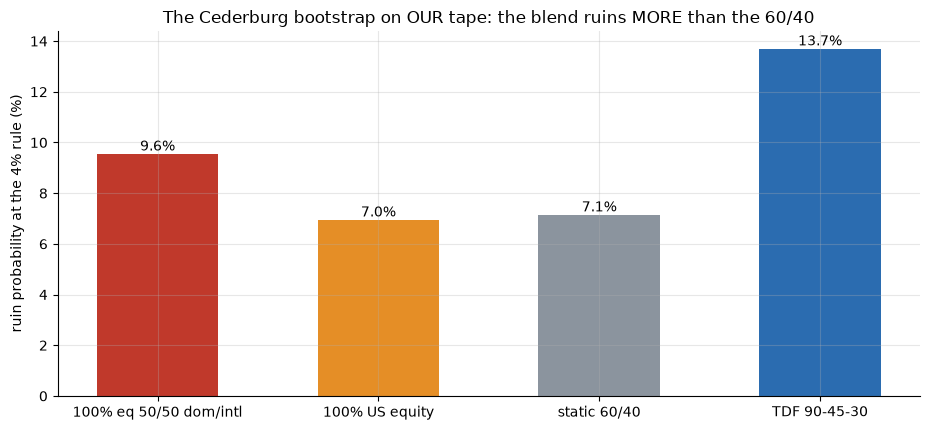

100% eq 50/50 dom/intl     pot@65 med  153.0  meanTW   577.3  medTW  290.6  ruin  9.55%
100% US equity             pot@65 med  214.2  meanTW  1433.7  medTW  660.8  ruin  6.95%
static 60/40               pot@65 med  148.9  meanTW   423.7  medTW  259.0  ruin  7.15%
TDF 90-45-30               pot@65 med  129.2  meanTW   172.3  medTW   95.5  ruin 13.70%


In [4]:
if HAVE_REAL:
    BU, BI, BB = st.block_lifetimes(US, INTL, BD, n_draws=2000, seed=598)
    rb = st.run_all(BU, BI, BB, wr=0.04)
    tab = {s: (float(np.median(rb[s]['wret'])), rb[s]['terminal'].mean(),
               float(np.median(rb[s]['terminal'])), 100*(~rb[s]['success']).mean())
           for s in STRATS}
else:
    rb, tab = None, R['boot']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = {'alleq': RED, 'alleq_dom': '#e58e26', 's6040': GREY, 'tdf': BLUE}
ax.bar([LBL[s] for s in STRATS], [tab[s][3] for s in STRATS],
       color=[cols[s] for s in STRATS], width=.55)
for i, s in enumerate(STRATS): ax.annotate(f'{tab[s][3]:.1f}%', (i, tab[s][3]),
                                           ha='center', va='bottom')
ax.set_ylabel('ruin probability at the 4% rule (%)')
ax.set_title('The Cederburg bootstrap on OUR tape: the blend ruins MORE than the 60/40')
plt.tight_layout(); plt.show()
for s in STRATS: print(f'{LBL[s]:<26} pot@65 med {tab[s][0]:6.1f}  meanTW {tab[s][1]:7.1f}  medTW {tab[s][2]:6.1f}  ruin {tab[s][3]:5.2f}%')

> 💡 In plain words: even with the paper's own resampling method, the blend's ruin (9.6%) sits *above* the 60/40's (7.2%) here. The paper's opposite ranking comes from its 38-country ingredient list: global bonds that lost to inflation for decades (ours: US 10-year, +2.4%/yr real) and international equity sampled from winning developed markets (ours: the DMS world-ex-US 4.3%/yr). Same recipe, different pantry, different dish.

### 4d · The lever that decides everything — the international leg

Re-run the whole race under each international assumption (the domestic row uses **no simulated data anywhere**):

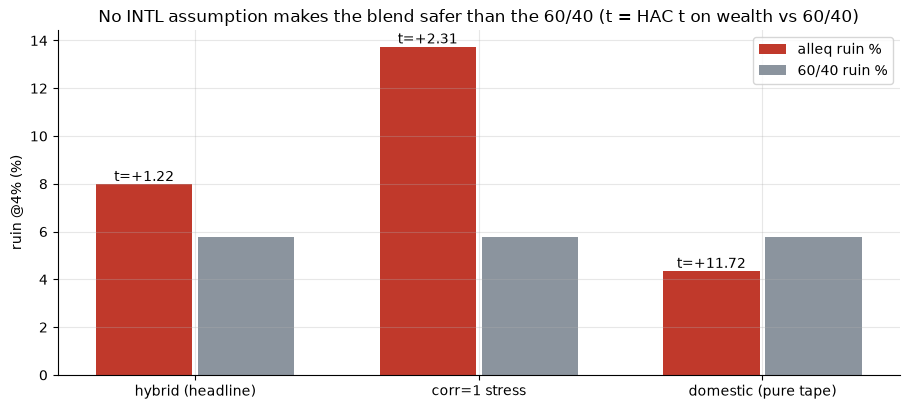

hybrid (headline)        ruin  7.98%  meanTW   350.6  HAC t vs 60/40 +1.22
corr=1 stress            ruin 13.74%  meanTW   228.0  HAC t vs 60/40 +2.31
domestic (pure tape)     ruin  4.34%  meanTW   559.4  HAC t vs 60/40 +11.72


In [5]:
if HAVE_REAL:
    sens = []
    for mode, lab in [('hybrid','hybrid (headline)'), ('corr1','corr=1 stress'),
                      ('domestic','domestic (pure tape)')]:
        d2 = data.real_returns(intl_mode=mode)
        g2 = st.cohort_year_returns(d2['US'].to_numpy(), d2['INTL'].to_numpy(), d2['BD'].to_numpy())
        r2 = st.run_all(g2[0], g2[1], g2[2], wr=0.04, strategies=('alleq','s6040'))
        dd = r2['alleq']['terminal'] - r2['s6040']['terminal']
        sens.append((lab, 100*(~r2['alleq']['success']).mean(),
                     r2['alleq']['terminal'].mean(), st.hac_tstat(dd, 840)))
else:
    sens = R['sens']
fig, ax = plt.subplots(figsize=(9.2, 4.2))
x = np.arange(len(sens))
ax.bar(x - .18, [s[1] for s in sens], .34, color=RED, label='alleq ruin %')
ax.bar(x + .18, [R['score']['s6040'][4]]*len(sens), .34, color=GREY, label='60/40 ruin %')
for i, s in enumerate(sens): ax.annotate(f't={s[3]:+.2f}', (i - .18, s[1]), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels([s[0] for s in sens])
ax.set_ylabel('ruin @4% (%)'); ax.legend()
ax.set_title('No INTL assumption makes the blend safer than the 60/40 (t = HAC t on wealth vs 60/40)')
plt.tight_layout(); plt.show()
for s in sens: print(f'{s[0]:<24} ruin {s[1]:5.2f}%  meanTW {s[2]:7.1f}  HAC t vs 60/40 {s[3]:+.2f}')

> 💡 In plain words: the knob that matters is the international **return level**, not the correlation. At the literature's 4.3%/yr the blend drags (*t* = +1.22); force correlation to 1 and the wealth *t* actually rises to +2.31 (less diversification, but the diff gets less noisy) while ruin gets *worse*; only replacing international with US equity (*t* = +11.72) certifies — and that variant is just [study 151](../../151-stocks-for-long-run/README.md)'s US-exceptionalism bet wearing a lifecycle costume. Ruin by withdrawal rate and the cost sweep tell the same story:

In [6]:
print('ruin % by withdrawal rate (cohorts):')
print('  wr    ' + ''.join(f'{LBL[s]:>26}' for s in STRATS))
for w in ('3.0','3.5','4.0','5.0'):
    print(f'  {w}% ' + ''.join(f'{R["ruin"][w][k]:>25.2f}%' for k in range(4)))
print()
print('cost sweep (one-way bps / ER bps): alleq vs 60/40')
for cb, er, mtw, ruin, t in R['costs']:
    print(f'  {cb:>3}/{er:>3}: meanTW {mtw:7.1f}  ruin {ruin:5.2f}%  HAC t {t:+.2f}')

ruin % by withdrawal rate (cohorts):
  wr        100% eq 50/50 dom/intl            100% US equity              static 60/40              TDF 90-45-30
  3.0%                      0.10%                     0.00%                     0.00%                     0.00%
  3.5%                      2.93%                     0.51%                     0.00%                     0.51%
  4.0%                      7.98%                     4.34%                     5.76%                    21.11%
  5.0%                     24.95%                    20.00%                    25.96%                    51.21%

cost sweep (one-way bps / ER bps): alleq vs 60/40
    0/  0: meanTW   364.9  ruin  7.98%  HAC t +1.21
   10/  5: meanTW   350.6  ruin  7.98%  HAC t +1.22
   25/ 20: meanTW   313.0  ruin  9.39%  HAC t +1.23


### 4d-bis · Seed-robustness — re-drawing the simulated residuals

The pre-2001 international leg is a *seeded* simulation, and single-seed verdicts are banned on this desk. Both head-to-heads re-run under **20 independent residual draws** (seeds 598–617; canonical numbers from `examples/verify.py`):

In [7]:
sr = R['seedrob']
print('HAC t across 20 residual re-draws of the simulated INTL leg:')
for pair, key in [('alleq - TDF  ', 'tdf'), ('alleq - 60/40', 's6040')]:
    m, lo, hi, n2 = sr[key]
    print(f'  {pair}: mean {m:+6.2f}  min {lo:+7.2f}  max {hi:+6.2f}  t>=2 in {n2}/20 seeds')
print(f"  ruin(alleq) > ruin(60/40) in {sr['ruin_worse_n']}/20 seeds -- a coin flip")
dm, t, ra, rt = sr['pure_tape_tdf']
print(f'  PURE TAPE alleq_dom - tdf_dom: dmeanTW {dm:+.1f}  HAC t {t:+.2f}  ruin {ra:.2f}% vs {rt:.2f}%')

HAC t across 20 residual re-draws of the simulated INTL leg:
  alleq - TDF  : mean  +6.58  min   +2.63  max +10.04  t>=2 in 20/20 seeds
  alleq - 60/40: mean  +2.62  min  -16.54  max +10.76  t>=2 in 13/20 seeds
  ruin(alleq) > ruin(60/40) in 9/20 seeds -- a coin flip
  PURE TAPE alleq_dom - tdf_dom: dmeanTW +437.7  HAC t +13.07  ruin 4.34% vs 11.52%


> 💡 In plain words: the certified half (all-equity vs the TDF) survives **every** residual draw — the headline seed's *t* = +2.63 is actually the *weakest* of the 20 — and holds on the pure tape with nothing simulated (*t* = +13.07). The 60/40 race is the opposite: the wealth *t* flips sign across draws and the ruin ranking is a coin flip (9/20) — nothing in that race is decided by market data, which is exactly why it stays uncertified.

### 4e · Synthetic control — the engine is faithful

20 independent seeded worlds per setting; detector = alleq vs 60/40, one-sample *t* across worlds. **Exact null:** at zero *arithmetic* equity premium, expected terminal wealth is identical for every weight schedule (products of independent gross returns), so the mean-wealth detector must read ~0. *(Machinery proof only — never cited as market evidence.)*

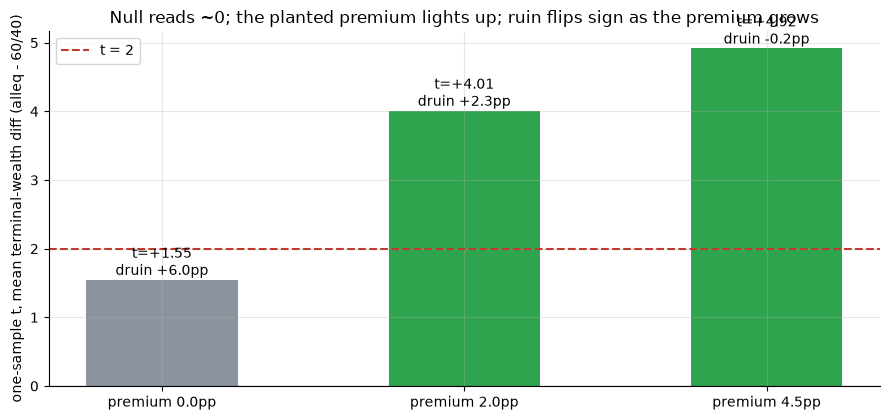

premium 0.0pp    dmeanTW     +3.2 (t +1.55)   druin  +5.95 pp (t +3.15)
premium 2.0pp    dmeanTW    +43.6 (t +4.01)   druin  +2.33 pp (t +1.14)
premium 4.5pp    dmeanTW   +342.8 (t +4.92)   druin  -0.23 pp (t -0.14)


In [8]:
res = [(f'premium {p:.1f}pp', st.control_premium_effect(p/100, wr=0.04, n_seeds=20))
       for p in (0.0, 2.0, 4.5)]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
vals = [r['dmean_t'] for _, r in res]
ax.bar([l for l, _ in res], vals, color=[GREY, GREEN, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(0, c='k', lw=.8)
for i, (l, r) in enumerate(res):
    ax.annotate(f"t={r['dmean_t']:+.2f}\ndruin {r['druin_mean']:+.1f}pp", (i, vals[i]),
                ha='center', va='bottom')
ax.set_ylabel('one-sample t, mean terminal-wealth diff (alleq - 60/40)')
ax.set_title('Null reads ~0; the planted premium lights up; ruin flips sign as the premium grows')
ax.legend(); plt.tight_layout(); plt.show()
for l, r in res: print(f"{l:<16} dmeanTW {r['dmean_mean']:+8.1f} (t {r['dmean_t']:+5.2f})   druin {r['druin_mean']:+6.2f} pp (t {r['druin_t']:+5.2f})")

> 💡 In plain words: the machinery is honest — at the exact null the wealth detector reads ~0 (*t* = +1.55) and 100% equity ruins **more** (+6.0 pp: pure vol, no reward); plant a 4.5 pp premium and wealth dominance lights up (*t* = +4.92) while the ruin gap closes to ~0. That is the real-tape verdict in miniature: the US leg's 4.5 pp premium certifies wealth, the international leg's ~2 pp does not, and nobody's ruin advantage certifies anywhere.

## 5 · The verdict

- **Signal `MIXED`** — split, spelled out: **Real vs the TDF** (ΔmeanTW +261, HAC *t* = +2.63, boot CI excludes 0; ruin -13.1 pp directional) · **not certified vs 60/40** for the paper's blend (*t* = +1.22, CI straddles 0, median tie) whose ruin is worse at the headline draw (7.98% vs 5.76%; Cederburg bootstrap agrees, 9.55% vs 7.15% — a coin flip across residual re-draws, 9/20: no ruin ranking vs 60/40 is decided by the data). Seed-robust: the TDF edge holds in 20/20 re-draws and on the pure tape (*t* = +13.07). The domestic variant certifies at *t* = +11.72 but is the US-exceptionalism bet, graded in study 151. Named: 85.7% of the INTL leg is calibrated simulation.
- **Tradability `FRAGILE`** — two index funds, *t* invariant to a 0→25 bps cost sweep, unlimited capacity; fragile because the certified edge needs 70 years, ruins the 1929 cohort, and the safety pitch is uncertified everywhere.
- **Worst cohorts `BUSTED`** — 1929: all-equity ruined (fy 16–18) vs 60/40 at 62×; 1966: rescued only by the simulated leg (corr-1 stress ruined, domestic ruined).

## 6 · Going further

- **The real bottleneck is data.** The paper's 38-country panel (and the DMS yearbook) are annual and proprietary; a public 150-year *monthly* international tape does not exist. Our calibrated leg is the honest substitute — the sensitivity grid brackets what any true tape could say.
- **Mortality and earnings.** We use a fixed 30-year retirement and flat real contributions; the paper couples mortality tables with an earnings process. Those choices move levels, not the ordering — the ordering is set by return levels and the 1940s–70s bond regime.
- **The siblings.** [151](../../151-stocks-for-long-run/README.md) grades the horizon claim `alleq_dom` rides; [596](../../596-bond-tent-glidepath/README.md) autopsies the decumulation glidepath (the TDF's back half); [173](../../173-four-percent-rule/README.md) shows the withdrawal *rate* is the lever that dominates all of this.

*The reproducible core is offline and deterministic; weights are age-only (one clean lag), every leg is real, and the simulated share of the INTL leg is labeled everywhere it appears. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*